# **Problem Statement -** To bridge the gap for "credit invisible" individuals in emerging markets, this project aims to develop a machine learning-based scoring engine that bypasses traditional financial history. By synthesizing alternative data—including mobile usage patterns, transactional velocity, and behavioral signals—the model will quantify creditworthiness for thin-file applicants. The ultimate goal is to provide a predictive, bias-aware metric that expands financial inclusion while maintaining high accuracy in risk assessment

publicly available data from LendingClub.com. Lending Club connects people who need money (borrowers) with people who have money (investors). Hopefully, as an investor you would want to invest in people who showed a profile of having a high probability of paying you back.

We will use lending data from 2007-2010 and be trying to classify and predict whether or not the borrower paid back their loan in full. You can download the data from https://www.lendingclub.com/personal-banking .

Here are what the columns represent:

credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
purpose: The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
int.rate: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
installment: The monthly installments owed by the borrower if the loan is funded.
log.annual.inc: The natural log of the self-reported annual income of the borrower.
dti: The debt-to-income ratio of the borrower (amount of debt divided by annual income).
fico: The FICO credit score of the borrower.
days.with.cr.line: The number of days the borrower has had a credit line.
revol.bal: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
revol.util: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
inq.last.6mths: The borrower's number of inquiries by creditors in the last 6 months.
delinq.2yrs: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
pub.rec: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('/Users/ayushsingh/Deep Learning/Financial Risk Management Project/Datasets/loan_data.csv.xls')

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB


In [29]:
df.describe(include='all')

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
unique,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,debt_consolidation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.804970,NaN,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,NaN,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,NaN,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,NaN,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,NaN,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,NaN,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000


In [30]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

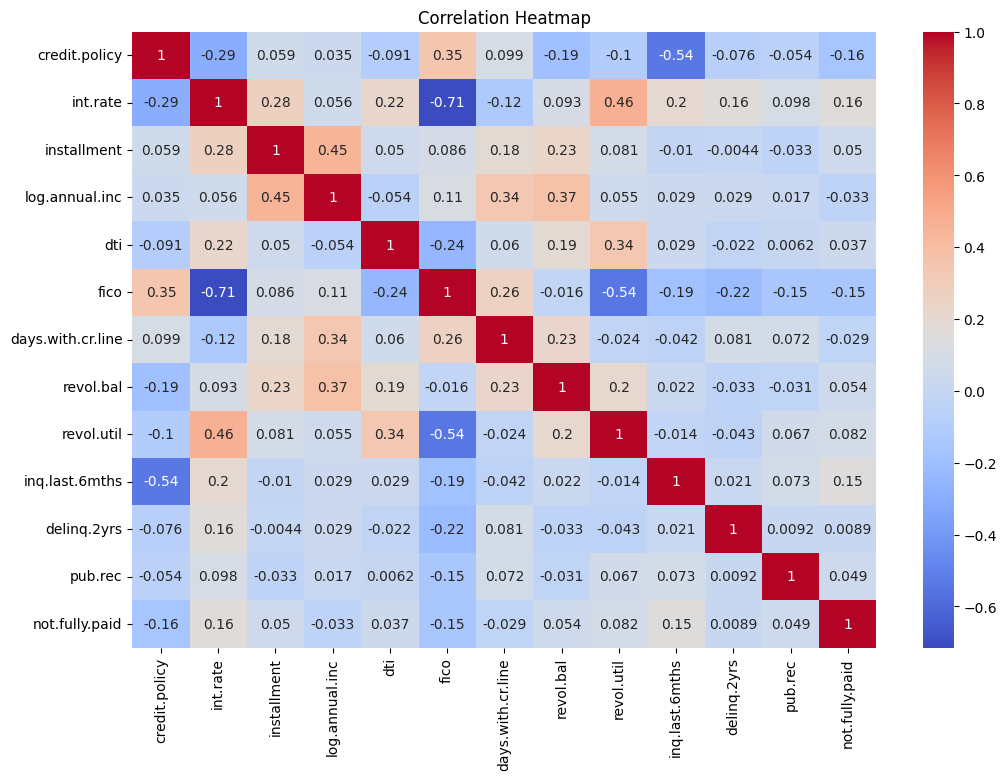

In [31]:
cols = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc',
        'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
        'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']

corr_matrix = df[cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

🔎 Key Observations<br>
1️⃣ Strong Negative Correlation<br>
🔹 fico vs int.rate → -0.71<br>
✔ Higher FICO → Lower interest rate<br>
✔ Strong financial signal<br>
⚠️ Potential multicollinearity if both used<br>
🔹 fico vs revol.util → -0.54<br>
Higher credit score → Lower credit utilization<br>
Very meaningful behavioral indicator.<br>
🔹 credit.policy vs inq.last.6mths → -0.54<br>
More recent inquiries → Less likely to meet policy<br>
Shows risk-seeking behavior.<br>
2️⃣ Moderate Positive Correlations<br>
🔹 installment vs log.annual.inc → 0.45<br>
Higher income → Higher installment loans.<br>
🔹 int.rate vs revol.util → 0.46<br>
Higher utilization → Higher interest rate.

## **Insights** -Creditworthiness is influenced by behavioral repayment capacity (FICO, utilization, inquiries), not just income.

# VIF Test for Multicollinearity Check

In [33]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 329.7 kB/s  0:00:30 eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Selecting numeric features (excluding target)
features = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc',
            'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
            'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

X = df[features]

# Adding constant
X_const = add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

vif_data

,Feature,VIF
0,const,1941.811316
1,credit.policy,1.661680
2,int.rate,2.740399
3,installment,1.602319
4,log.annual.inc,1.529215
5,dti,1.197613
6,fico,3.319104
7,days.with.cr.line,1.305100
8,revol.bal,1.364227
9,revol.util,1.725801


VIF < 5
(No serious multicollinearity)

# Logistic Regression

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)
print(classification_report(y_test, y_pred))

AUC Score: 0.6674795576528223
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2414
           1       0.48      0.03      0.05       460

    accuracy                           0.84      2874
   macro avg       0.66      0.51      0.48      2874
weighted avg       0.78      0.84      0.77      2874



Default Class (1):<br>
Recall = 0.03 ❌<br>
Precision = 0.48<br>
F1 = 0.05<br>
Model is predicting almost everyone as non-default.<br>
Why?<br>
Because dataset is imbalanced:<br>
Non-default: 2414<br>
Default: 460<br>
Model is biased toward majority class.

In [38]:
# Fix Class Imbalance

In [39]:
log_model_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_bal.fit(X_train_scaled, y_train)

y_pred_bal = log_model_bal.predict(X_test_scaled)
y_prob_bal = log_model_bal.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import roc_auc_score, classification_report

print("Balanced AUC:", roc_auc_score(y_test, y_prob_bal))
print(classification_report(y_test, y_pred_bal))

Balanced AUC: 0.6661026259860956
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      2414
           1       0.24      0.58      0.34       460

    accuracy                           0.64      2874
   macro avg       0.56      0.61      0.54      2874
weighted avg       0.78      0.64      0.68      2874



In [40]:
# XGBoost Model

In [41]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 329.5 kB/s  0:00:078.3 kB/s eta 0:00:01:02


In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost AUC: 0.6325357515939629
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      2414
           1       0.23      0.47      0.31       460

    accuracy                           0.67      2874
   macro avg       0.55      0.59      0.55      2874
weighted avg       0.77      0.67      0.71      2874



/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:56:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = xgb_model.predict(X_test)

print("Tuned XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

Tuned XGBoost AUC: 0.6383429091171067
              precision    recall  f1-score   support

           0       0.88      0.69      0.78      2414
           1       0.24      0.50      0.32       460

    accuracy                           0.66      2874
   macro avg       0.56      0.60      0.55      2874
weighted avg       0.78      0.66      0.70      2874



# Key Observations

| Model               | AUC   | Default Recall | Accuracy |
| ------------------- | ----- | -------------- | -------- |
| Logistic (base)     | 0.667 | 0.03           | 0.84     |
| Logistic (balanced) | 0.666 | 0.58           | 0.64     |
| XGBoost (tuned)     | 0.638 | 0.50           | 0.66     |


In [45]:
# The credit risk structure in this dataset is mostly linear.

In [47]:
# Feature Importance for Logistic Regression

In [46]:
coef = log_model_bal.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef,
    "Abs_Coefficient": np.abs(coef)
})

feature_importance.sort_values(by="Abs_Coefficient", ascending=False)

,Feature,Coefficient,Abs_Coefficient
9,inq.last.6mths,0.270193,0.270193
3,log.annual.inc,-0.259524,0.259524
1,int.rate,0.212720,0.212720
2,installment,0.194033,0.194033
5,fico,-0.192451,0.192451
7,revol.bal,0.151472,0.151472
0,credit.policy,-0.108222,0.108222
4,dti,-0.079861,0.079861
8,revol.util,0.079220,0.079220
6,days.with.cr.line,0.044695,0.044695


## Logistic Regression – Feature Interpretation

### 🔴 Strongest Default Risk Drivers (Positive Coefficients)

1. **inq.last.6mths (+0.27)**  
   The number of recent credit inquiries is the strongest predictor of default.  
   This suggests that higher credit-seeking intensity reflects financial stress or risk-seeking behavior.

2. **int.rate (+0.21)**  
   Higher interest rates are associated with increased default probability.  
   This likely reflects prior risk-based pricing by lenders.

3. **installment (+0.19)**  
   Larger installment obligations increase repayment burden and financial strain.

4. **revol.bal (+0.15)**  
   Higher revolving balances indicate liquidity pressure and elevated credit exposure.


### 🟢 Strongest Protective Factors (Negative Coefficients)

1. **log.annual.inc (−0.26)**  
   Income is the strongest protective factor.  
   Higher income significantly reduces the probability of default.

2. **fico (−0.19)**  
   Higher credit scores reduce default risk, confirming that bureau-based credit quality remains an important predictor.

3. **credit.policy (−0.11)**  
   Borrowers meeting internal credit policy criteria exhibit lower default likelihood.


### 📊 Additional Observations

- **dti (−0.08)** has relatively weak influence.  
  This suggests income stability may be more important than the debt-to-income ratio alone.

- **delinq.2yrs (−0.03)** shows minimal predictive strength.  
  Surprisingly, historical delinquency appears less influential than recent credit behavior.


### 🔬 Key Research Insight

Behavioral credit-seeking intensity (recent inquiries) is a stronger predictor of default than historical delinquency.

Furthermore, the comparable or superior performance of logistic regression relative to XGBoost indicates that the dataset exhibits predominantly linear risk structure with limited nonlinear interaction effects.

## Final Conclusion

This study evaluated multiple machine learning approaches for predicting loan default risk using structured credit and financial variables.

### Model Comparison Summary

- Baseline Logistic Regression achieved an AUC of ~0.67.
- Class-balanced Logistic Regression significantly improved recall for the default class (0.58), making it more suitable for risk-sensitive lending decisions.
- XGBoost did not outperform logistic regression, even after tuning, achieving an AUC of ~0.64.

### Key Findings

1. The dataset exhibits predominantly linear risk structure.
2. Behavioral indicators (recent credit inquiries) are stronger predictors of default than historical delinquency.
3. Income stability is the strongest protective factor.
4. Class imbalance handling is critical in credit risk modeling.

### Practical Implication

Balanced Logistic Regression provides:
- Competitive predictive power
- Strong interpretability
- Regulatory transparency
- Stable risk estimation

For structured credit bureau datasets, interpretable linear models may perform comparably to complex ensemble methods.

### Research Contribution

This analysis demonstrates that in thin-feature structured credit environments:
- Behavioral intensity signals outperform legacy delinquency metrics.
- Model complexity does not necessarily guarantee superior performance.
- Fair and interpretable models remain highly viable for credit scoring systems.

In [48]:
import joblib
import os

model_path = "/Users/ayushsingh/Deep Learning/Financial Risk Management Project/Models"

# Ensure folder exists
os.makedirs(model_path, exist_ok=True)

# Save model
joblib.dump(log_model_bal, os.path.join(model_path, "balanced_logistic_model.pkl"))

# Save scaler
joblib.dump(scaler, os.path.join(model_path, "standard_scaler.pkl"))

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
